In [ ]:
#Names: Trevor Henderson, Jorge Angon
#dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# Import pandas and numpy for data handling and numeric work
import pandas as pd
import numpy as np

# Import XGBoost for binary classification
import xgboost as xgb

# Import train/test split and evaluation tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import matplotlib for confusion matrix visualization
import matplotlib.pyplot as plt

In [ ]:
# Load the Telco Customer Churn dataset from the CSV file
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Show the overall shape so we can confirm it loaded correctly
print("Dataset shape:", df.shape)

# Preview the first few rows to understand the columns
print(df.head())

Dataset shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

In [ ]:
# Import LabelEncoder to convert categorical text values into numeric form
from sklearn.preprocessing import LabelEncoder

# Remove duplicate rows so repeated customer records do not influence model training
df = df.drop_duplicates()

# Convert TotalCharges column from text to numeric format
# errors="coerce" turns invalid values into NaN so they can be filled
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Replace missing numeric values with the median value
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Initialize LabelEncoder object for converting categorical columns
le = LabelEncoder()

# Convert all object-type categorical columns into numeric values
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
# Separate predictor variables from the target column
X = df.drop("Churn", axis=1)

# Store churn column as the variable the model will predict
y = df["Churn"]

# This prepares the dataset in the same format used in the example script

In [ ]:
print("Total samples:", len(df))
print("\nClass distribution:")
print(df["Churn"].value_counts().sort_index())

Total samples: 7043

Class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# Split dataset into training (70%) and testing (30%) sets
# random_state ensures results remain consistent each time code runs
# stratify keeps class distribution balanced between both datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
# Initialize XGBoost classifier
model = xgb.XGBClassifier(
    max_depth=3,
    n_estimators=50,
    learning_rate=0.1,
    objective="binary:logistic",
    random_state=42,
    eval_metric="logloss"
)

# Print model parameters BEFORE training (matches example code structure)
print("Model parameters:")
print(f"  - Max tree depth: {model.max_depth}")
print(f"  - Number of trees: {model.n_estimators}")
print(f"  - Learning rate: {model.learning_rate}")

# Train the model
model.fit(X_train, y_train)

# Confirmation message AFTER training to suppress notebook output block
print("Model training complete.")

Model parameters:
  - Max tree depth: 3
  - Number of trees: 50
  - Learning rate: 0.1
Model training complete.


In [ ]:
# Generate predictions on both training and testing datasets
# Training predictions evaluate how well the model learned patterns
# Testing predictions evaluate performance on unseen data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Generate probability estimates showing prediction confidence
y_test_proba = model.predict_proba(X_test)

# Print confirmation message after predictions are completed
print("Predictions generated successfully.")

Predictions generated successfully.


In [ ]:
# Calculate training accuracy to measure how well model learned patterns
train_accuracy = accuracy_score(y_train, y_train_pred)

# Calculate testing accuracy to evaluate real-world predictive performance
test_accuracy = accuracy_score(y_test, y_test_pred)

# Display both accuracy scores for comparison
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# Confirmation message for step completion
print("Accuracy evaluation complete.")

Training Accuracy: 0.8184584178498986
Testing Accuracy: 0.7931850449597728
Accuracy evaluation complete.


In [ ]:
# Print precision, recall, and F1-score for deeper evaluation of predictions
# Precision measures correct positive predictions
# Recall measures how many actual positives were identified correctly
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Confirmation message after classification metrics are displayed
print("Classification metrics generated successfully.")


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1552
           1       0.66      0.47      0.55       561

    accuracy                           0.79      2113
   macro avg       0.74      0.69      0.71      2113
weighted avg       0.78      0.79      0.78      2113

Classification metrics generated successfully.


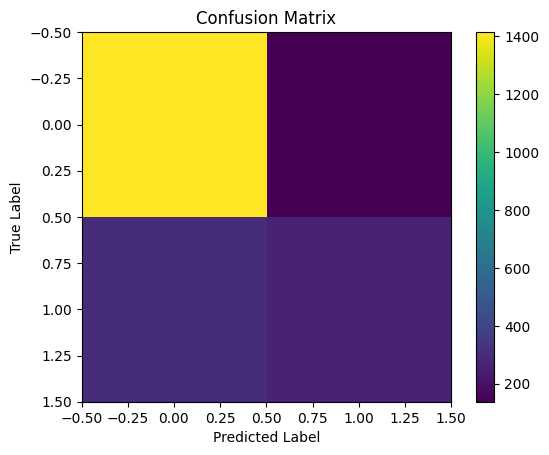

Confusion matrix visualization complete.


In [ ]:
# Create confusion matrix comparing predicted values against actual values
cm = confusion_matrix(y_test, y_test_pred)

# Display confusion matrix visually for easier interpretation
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

# Label axes so chart clearly shows prediction vs actual comparison
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# Confirmation message after visualization completes
print("Confusion matrix visualization complete.")

In [ ]:
# Select the first 5 rows from the test dataset
sample_subset = X_test.iloc[:5]

# Get actual values for comparison
actual_subset = y_test.iloc[:5]

# Generate predictions for those rows
subset_predictions = model.predict(sample_subset)

# Print predictions vs actual values
print("Predictions vs Actual Values:")
for i in range(len(subset_predictions)):
    print(f"Sample {i+1}: Predicted = {subset_predictions[i]}, Actual = {actual_subset.iloc[i]}")

# Calculate accuracy score for these predictions
subset_accuracy = accuracy_score(actual_subset, subset_predictions)

# Display accuracy result
print("\nAccuracy for these sample predictions:", subset_accuracy)

Predictions vs Actual Values:
Sample 1: Predicted = 1, Actual = 1
Sample 2: Predicted = 0, Actual = 0
Sample 3: Predicted = 1, Actual = 1
Sample 4: Predicted = 0, Actual = 0
Sample 5: Predicted = 0, Actual = 0

Accuracy for these sample predictions: 1.0


Summary paragraph: XGBoost is a machine learning algorithm that helps computers make better predictions by learning from mistakes step by step. Instead of relying on just one decision, it builds many small decision trees that work together to improve accuracy over time. In this project, the model was used to analyze a telecom customer churn dataset to predict whether a customer is likely to leave a company based on things like how long they have been a customer, and how much they pay each month. This kind of prediction can help companies identify customers who might leave before it happens so they can take action to keep them. In the real world, models like this are useful for data analysis because they help organizations find patterns in large datasets and make better decisions about customer support, pricing strategies, and long-term planning.